# Exercise 10.1: Gauss-Seidel Iteration in Two Dimensions for Various Charge Configurations

Implement the Gauss-Seidel method in two dimensions and calculate potential $\phi(x,y)$ in a rectangle of sides of length 1, using the Poisson equation in the form:

$-\left(\frac{ \partial^2 }{\partial x^2} + \frac{ \partial^2 }{\partial y^2}\right) \phi(x,y) = S(x,y)$.


Consider the following three charge configurations (i.e. source configurations):

i) Circular charge of constant density at $(x,y)=(0.5,0.5)$:
$$
S(x,y)=
\begin{cases}
10& \quad \text{if $(x-0.5)^2 + (y-0.5)^2 < 0.05^2 $;}\\ 
0& \quad \text{otherwise.}\\ 
\end{cases}
$$


ii) Two parallel rectangular lines of constant charge density:
$$
S(x,y)=
\begin{cases}
10& \quad \text{if $x > 0.2$, $x<0.8$, $y>0.78$, $y<0.82$;}\\ 
-10&\quad \text{if $x > 0.2$, $x<0.8$, $y>0.18$, $y<0.22$;}\\
& \quad \text{otherwise.}\\ 
\end{cases}
$$

iii) A rectangular line of charge and a circular charge:
$$
S(x,y)=
\begin{cases}
10&\quad \text{if $x > 0.2$, $x<0.8$, $y>0.18$, $y<0.22$;}\\
-10& \quad \text{if $(x-0.5)^2 + (y-0.8)^2 < 0.05^2 $;}\\ 
& \quad \text{otherwise.}\\ 
\end{cases}
$$

Set the boundary conditions $\phi(x,0) = \phi(0,y) = 0$ at the edges of the unit rectangle. You may investigate which values of the relaxation parameter, $\omega$ are optimal for your grid size, which should be $N\times N$ with $N\sim 50$. You will need to perform $\mathcal{O}(\text{few }100)$ iterations.

For each case:

(a) Plot the energy function against the number of iterations and show that it converges.

(b) Plot a contour plot of the potentials (see Chapter 1 for an example of contour plots, not that the resulting 2D array will need to be transposed in your calculation). 

(c) Comment on whether the resulting potentials qualitatively agree with your expectations. 

Solution:

Let's first implement the Gauss-Seidel method in generality and then define the source functions corresponding to our charge distributions. 

In [1]:
import numpy as np

# the energy function for a given array of phis,
# a given source function S,
# and the lattice intervals N
def Energy(phi, S, N):
    """Returns the two-dimensional energy given the array of phis and the source term S"""
    E = 0
    h = 1/N # the lattice spacing, equal in each dimension
    for i in range(1,N+1): 
        # calculate xi:
        xi = i*h
        for j in range(1,N+1): 
            yj = j*h
            # add to the current sum. 
            # the last element will be zero, so we can sum both terms:
            # the last non-zero term in the first term will be: phi[N] - phi[N-1], with phi[N] = 0
            # and in the second term it should be phi[N-1] as well, as required by the theoretical sum
            E = E + 0.5 * ((phi[i][j] - phi[i-1][j])**2 + (phi[i][j]-phi[i][j-1])) - h**2 * S(xi,yj) * phi[i][j]
    # return the value
    return E

# the source term: 
def SfuncParallelLines(x,y):
    """The source term for the differential equation: Parallel Lines of Charge"""
    if y > 0.18 and y < 0.22 and x < 0.8 and x > 0.2:
        result = -10
    elif y > 0.78 and y < 0.82 and x < 0.8 and x > 0.2:
        result = 10
    else:
        result = 0
    return result


# the source term: 
def SfuncCirc(x,y):
    """The source term for the differential equation: Circular Charge"""
    # a circular piece of constant charge of radius 0.01 at [0.5, 0.5]
    if np.sqrt((x-0.5)**2 + (y-0.5)**2) < 0.05:
        result = -10
    else:
        result = 0
    return result

# the source term: 
def SfuncCircParallelLine(x,y):
    """The source term for the differential equation: Circular Charge and Parallel Line"""
    # a circular piece of constant charge of radius 0.01 at [0.5, 0.5]
    if np.sqrt((x-0.5)**2 + (y-0.2)**2) < 0.05:
        result = -10
    # and a line: 
    elif y > 0.78 and y < 0.82 and x < 0.8 and x > 0.2:
        result = 10
    else:
        result = 0
    return result


# function that sweeps through the lattice and calculates the new values:
# the input should be the number of lattice intervals N
# the source function Sfunc 
# the number of iterations niter
# the value of the relaxation parameter omega
def GaussSeidel(S, N, niter, omega):
    """Applies the Gauss-Seidel iterative procedure in two dimensions"""
    # calculate the spacing between lattice points
    h = 1/N
    # first setup the starting array for phi:
    phi = np.zeros((N+1, N+1)) # there are N+1 points for N intervals
    # empty list for energy evolution
    E = []
    # loop over iterations: 
    for n in range(niter):
        # loop over the phase space:
        for i in range(1, N): # stop at N-1, since phi[N] = 0 is a b.c.
            xi = i*h # the value of x at point (i,j)
            for j in range(1, N): # stop at N-1, since phi[N] = 0 is a b.c.
                yj = j*h # the value of y at point (i,j)
                phi[i][j] = (1-omega) * phi[i][j] + (omega/4)*(phi[i+1][j] + phi[i-1][j] + phi[i][j+1] + phi[i][j-1] + h**2 * S(xi,yj))
        # at the end of the iteration, get the energy:
        Ei = Energy(phi, S, N)
        E.append(Ei)
    return phi, np.array(E)

We are now ready to obtain the solution for each of the three cases, starting with the circular charge:

In [2]:
N = 50
niter = 1000
omega = 1.5
phiFinalCirc, EnergyIter = GaussSeidel(SfuncCirc, N, niter, omega)

Let's plot the energy versus iterations: 

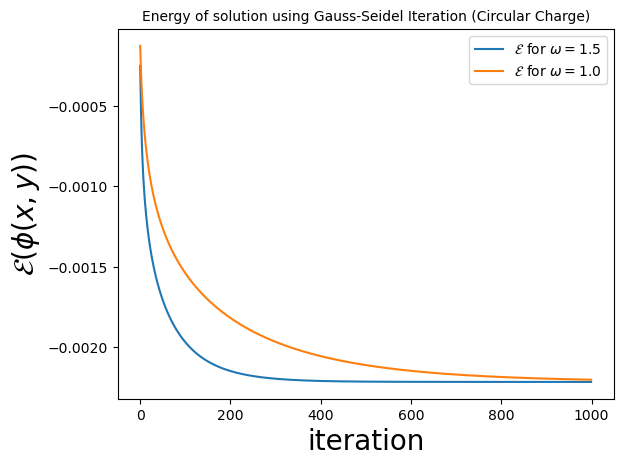

In [4]:
# Plot the solution: 
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'iteration', fontsize=20) # set the x label
ax.set_ylabel(r'$\mathcal{E}(\phi(x,y))$', fontsize=20) # set the y label. Note that the 'r' is necessary to remove the need for double slashes. You can use LaTeX! 
ax.set_title('Energy of solution using Gauss-Seidel Iteration (Circular Charge)', fontsize=10) # set the title 

# make a one-dimensional plot using the above arrays, add a custom label
xiter = range(niter)
ax.plot(xiter,EnergyIter, label=r'$\mathcal{E}$ for $\omega=1.5$') 
ax.plot(xiter,EnergyIter10, label=r'$\mathcal{E}$ for $\omega=1.0$') 


# construct the legend:
ax.legend(loc='upper right')  # Add a legend

plt.show() # show the plot here

Let's plot contours of the solution: 

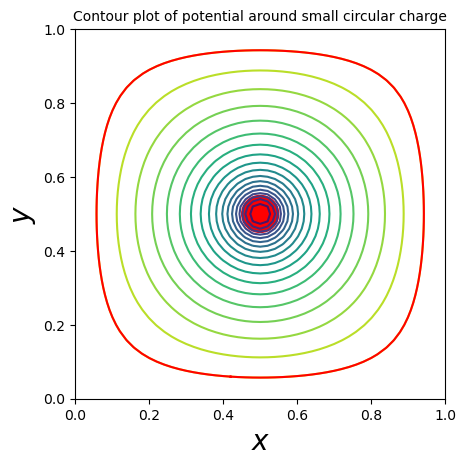

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# make dependent variables:  
X, Y = np.meshgrid(np.linspace(0, 1, N+1), np.linspace(0, 1, N+1))

# now calculate a function over this grid, e.g.: 
levels = np.linspace(np.min(phiFinalCirc), np.max(phiFinalCirc), 20) # calculate six 'levels' on the contour

# plot
fig, ax = plt.subplots()

# make the contour:
contours = ax.contour(X, Y, phiFinalCirc.T, levels=levels)

paths = contours.get_paths()
v = paths[-2].vertices
x = v[:, 0]
y = v[:, 1]
ax.plot(x,y, color='red')
# set title:
ax.set_title("Contour plot of potential around small circular charge", fontsize=10)

# set labels
ax.set_xlabel(r'$x$',fontsize=20)
ax.set_ylabel(r'$y$',fontsize=20)

# plot the circular charge:
circle1 = plt.Circle((0.5, 0.5), 0.05, color='r')
ax.add_patch(circle1)

ax.set_aspect(1)

plt.show()

As expected, outside the charge distribution, this looks like the potential for a point charge at $(0.5, 0.5)$. 

Let's now consider the case of parallel lines: 

In [132]:
N = 50
niter = 1000
omega = 1.5
phiFinalParallelLines, EnergyIter = GaussSeidel(SfuncParallelLines, N, niter, omega)

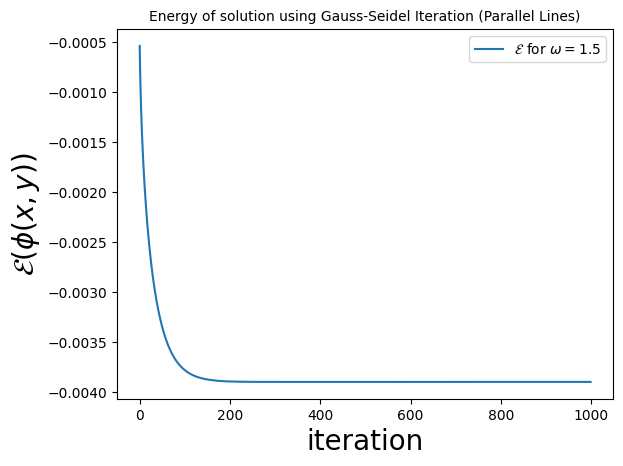

In [117]:
# Plot the solution: 
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'iteration', fontsize=20) # set the x label
ax.set_ylabel(r'$\mathcal{E}(\phi(x,y))$', fontsize=20) # set the y label. Note that the 'r' is necessary to remove the need for double slashes. You can use LaTeX! 
ax.set_title('Energy of solution using Gauss-Seidel Iteration (Parallel Lines)', fontsize=10) # set the title 

# make a one-dimensional plot using the above arrays, add a custom label
xiter = range(niter)
ax.plot(xiter,EnergyIter, label=r'$\mathcal{E}$ for $\omega=1.5$') 


# construct the legend:
ax.legend(loc='upper right')  # Add a legend

plt.show() # show the plot here

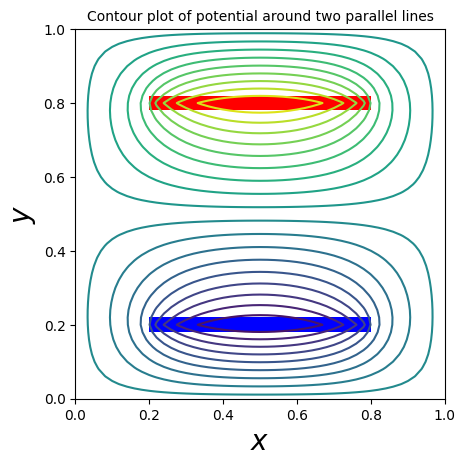

In [116]:
import matplotlib.pyplot as plt
import numpy as np

# make dependent variables:  
X, Y = np.meshgrid(np.linspace(0, 1, N+1), np.linspace(0, 1, N+1))

# now calculate a function over this grid, e.g.: 
levels = np.linspace(np.min(phiFinalParallelLines), np.max(phiFinalParallelLines), 20) # calculate six 'levels' on the contour

# plot
fig, ax = plt.subplots()

# make the contour:
ax.contour(X, Y, phiFinalParallelLines.T, levels=levels)

# set title:
ax.set_title("Contour plot of potential around two parallel lines", fontsize=10)

# set labels
ax.set_xlabel(r'$x$',fontsize=20)
ax.set_ylabel(r'$y$',fontsize=20)

# plot the charges:
rectangle1 = plt.Rectangle((0.2, 0.78), 0.6, 0.04, fill=True, facecolor='red')
rectangle2 = plt.Rectangle((0.2, 0.18), 0.6, 0.04, fill=True, facecolor='blue')
ax.add_patch(rectangle1)
ax.add_patch(rectangle2)


ax.set_aspect(1)

plt.show()

Again, this looks as expected: approximately uniform in the region between the plates.

And finally, let's look at the circle-parallel line configuration: 

In [133]:
N = 50
niter = 1000
omega = 1.5
phiFinalCircParallelLine, EnergyIter = GaussSeidel(SfuncCircParallelLine, N, niter, omega)

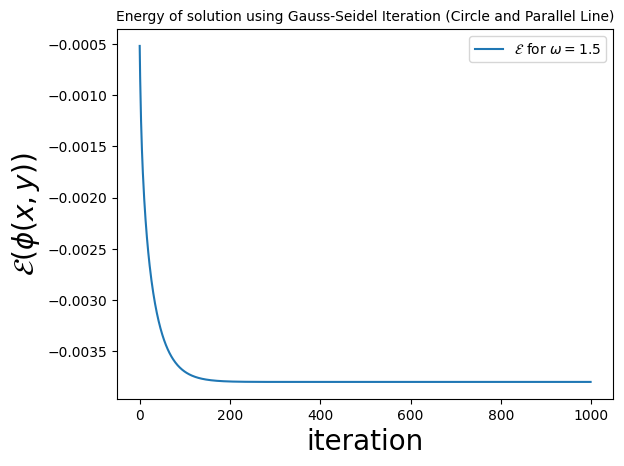

In [126]:
# Plot the solution: 
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'iteration', fontsize=20) # set the x label
ax.set_ylabel(r'$\mathcal{E}(\phi(x,y))$', fontsize=20) # set the y label. Note that the 'r' is necessary to remove the need for double slashes. You can use LaTeX! 
ax.set_title('Energy of solution using Gauss-Seidel Iteration (Circle and Parallel Line)', fontsize=10) # set the title 

# make a one-dimensional plot using the above arrays, add a custom label
xiter = range(niter)
ax.plot(xiter,EnergyIter, label=r'$\mathcal{E}$ for $\omega=1.5$') 

# construct the legend:
ax.legend(loc='upper right')  # Add a legend

plt.show() # show the plot here

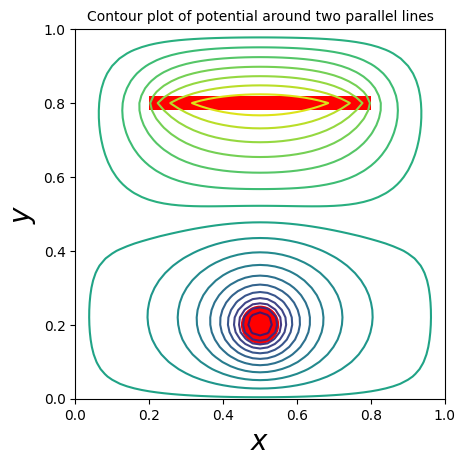

In [128]:
import matplotlib.pyplot as plt
import numpy as np

# make dependent variables:  
X, Y = np.meshgrid(np.linspace(0, 1, N+1), np.linspace(0, 1, N+1))

# now calculate a function over this grid, e.g.: 
levels = np.linspace(np.min(phiFinalCircParallelLine), np.max(phiFinalCircParallelLine), 20) # calculate six 'levels' on the contour

# plot
fig, ax = plt.subplots()

# make the contour:
ax.contour(X, Y, phiFinalCircParallelLine.T, levels=levels)

# set title:
ax.set_title("Contour plot of potential around two parallel lines", fontsize=10)

# set labels
ax.set_xlabel(r'$x$',fontsize=20)
ax.set_ylabel(r'$y$',fontsize=20)

# plot the charges:
# rectangular line:
rectangle1 = plt.Rectangle((0.2, 0.78), 0.6, 0.04, fill=True, facecolor='red')
ax.add_patch(rectangle1)
# plot the circular charge:
circle1 = plt.Circle((0.5, 0.2), 0.05, color='r')
ax.add_patch(circle1)

ax.set_aspect(1)

plt.show()

This again looks as expected: near the circular charge, the equipotential lines are circular, and closer to the rectangular charge they turn parallel to it. 